# 02 - Visual comparison of the results

Nothing new is computed here: we **look** at the results produced by
`01_inverse_solutions.ipynb` and try to answer the question of the hands-on —
*how much of the cortical map I am looking at comes from the data, and how much
from my methodological choices?*

Contents:

1. **interactive exploration**: open the 3D window, rotate the brain, move through time;
2. cortical maps: **same instant, different methods**;
3. cortical maps: **same method, different regularization**;
4. ROI time courses across methods and SNR values;
5. peaks: latency, position, MNI coordinates;
6. a quantitative index of the **spatial extent** of the solution.

## 0. Setup

The constants must be **the same** as in notebook 01.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne

mne.set_log_level("warning")
mne.viz.set_3d_backend("pyvistaqt")   # separate interactive windows

PROJECT = Path.cwd()
if not (PROJECT / "data").exists() and (PROJECT.parent / "data").exists():
    PROJECT = PROJECT.parent

DATA = PROJECT / "data"
SUBJECTS_DIR = PROJECT / "subjects"
RESULTS = PROJECT / "results"
STC_DIR = RESULTS / "stc"
FIG_DIR = RESULTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SUBJECT = "sub-01"
CONDITIONS = ["famous", "unfamiliar", "scrambled"]
METHODS = ["MNE", "dSPM", "sLORETA"]
SNRS = [1.0, 2.0, 3.0, 5.0]
COLORS = {"famous": "#1f77b4", "unfamiliar": "#ff7f0e", "scrambled": "#2ca02c"}
METHOD_COLORS = {"MNE": "#4c72b0", "dSPM": "#dd8452", "sLORETA": "#55a868"}

# Reference configuration used throughout the notebook
COND_REF = "famous"
METHOD_REF = "dSPM"
SNR_REF = 3.0
TIME_REF = 0.17   # instant to compare, in seconds


def stc_path(cond, method, snr):
    return STC_DIR / f"{SUBJECT}_cond-{cond}_method-{method}_snr-{snr:g}"


def load_stc(cond, method, snr):
    return mne.read_source_estimate(str(stc_path(cond, method, snr)))


peaks = pd.read_csv(RESULTS / "summary_peaks.csv")
roi_df = pd.read_csv(RESULTS / "roi_timecourses.csv")
ROI_NAMES = list(dict.fromkeys(roi_df["roi"]))

print(f"{len(peaks)} solutions indexed, {len(ROI_NAMES)} ROIs")
peaks.head()

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


36 solutions indexed, 6 ROIs


,condition,method,snr,lambda2,peak_hemi,peak_vertex,peak_latency_s,peak_amplitude,mni_x,mni_y,mni_z
0,famous,MNE,1.0,1.00,lh,1085,0.250000,2.356194e-10,-24.7,-99.2,20.6
1,unfamiliar,MNE,1.0,1.00,lh,4304,0.220000,2.710553e-10,-23.0,-99.1,-3.2
2,scrambled,MNE,1.0,1.00,lh,240,0.293333,2.714262e-10,-15.7,-103.2,14.0
3,famous,MNE,2.0,0.25,rh,7419,0.230000,4.989576e-10,30.8,-95.6,-12.5
4,unfamiliar,MNE,2.0,0.25,rh,7419,0.230000,5.106167e-10,30.8,-95.6,-12.5


## 1. Interactive exploration

Before producing any static figure, look at one solution in the **interactive 3D
window**. This is where you actually get a feeling for the data: the still images
that follow are only a way of freezing what you see here.

The cell below opens a separate window (PyVista/Qt). What you can do in it:

* **rotate** the brain by dragging with the left mouse button;
* **zoom** with the scroll wheel, **pan** with the middle button;
* drag the **time slider** at the bottom to move through the epoch, or press
  *Play* to watch the activation as a movie;
* change **colour limits**, **smoothing** and **surface** in the left-hand panel;
* switch the **orientation** (lateral, medial, dorsal, ventral, frontal, occipital)
  from the drop-down menu;
* tick an **annotation** (for example `aparc`) to overlay the anatomical
  parcellation, then click on a region to see its time course.

Keep the window open as long as you need, then close it (or run the last cell of
this section).

In [4]:
stc = load_stc(COND_REF, METHOD_REF, SNR_REF)

brain = stc.plot(
    subject=SUBJECT, subjects_dir=SUBJECTS_DIR,
    surface="inflated", hemi="both", views="lateral",
    initial_time=TIME_REF, time_unit="s",
    time_viewer=True, show_traces=True,     # time slider + interactive time courses
    size=(1000, 700), background="white",
    title=f"{COND_REF} - {METHOD_REF}, SNR={SNR_REF:g}",
)

### 1.1 Driving the window from code

Everything you can do with the mouse can also be done programmatically, which is
what makes a figure reproducible: the same three lines always give the same view.

In [5]:
brain.set_time(0.17)                 # move to a given latency (s)
brain.show_view("ventral")           # lateral, medial, dorsal, ventral, frontal, occipital
brain.save_image(str(FIG_DIR / "02_interactive_ventral.png"))
print("saved:", FIG_DIR / "02_interactive_ventral.png")

saved: C:\Users\Arianna\Desktop\Hands_on\results\figures\02_interactive_ventral.png


### 1.2 Two windows side by side

To compare two solutions honestly they must show the same instant with the same
colour scale. `mne.viz.link_brains` synchronizes time cursor and colour limits
across windows: move one, the other follows.

The two windows open on top of each other — drag them apart before comparing.

In [6]:
brains = []
for method in ["MNE", "sLORETA"]:
    b = load_stc(COND_REF, method, SNR_REF).plot(
        subject=SUBJECT, subjects_dir=SUBJECTS_DIR,
        hemi="both", views="lateral",
        initial_time=TIME_REF, time_unit="s",
        time_viewer=True, show_traces=False,
        size=(800, 600), background="white",
        title=f"{method} - {COND_REF}, SNR={SNR_REF:g}",
    )
    brains.append(b)

mne.viz.link_brains(brains, time=True, camera=True)

In [7]:
# Close the interactive windows when you are done
brain.close()
for b in brains:
    b.close()
print("3D windows closed")

3D windows closed


## 2. Cortical maps: comparison across methods

We now take **one instant** and **one SNR** and change only the method.

An important note about scaling: MNE, dSPM and sLORETA have **different units**
(ampere-metre, noise units, standardized units), so comparing the numbers makes no
sense. This is why every panel is scaled on its own percentiles: what we compare is
the **spatial pattern**, not the amplitude.

In [8]:
# Common percentiles: we compare the spatial distribution, not the absolute values
CLIM = dict(kind="percent", lims=(93, 97, 99.9))


def brain_screenshot(stc, time, size=(900, 650), clim=CLIM):
    """Open the 3D rendering, grab the image and close the window."""
    brain = stc.plot(
        subject=SUBJECT, subjects_dir=SUBJECTS_DIR,
        hemi="split", views=["lat", "med"],
        initial_time=time, time_unit="s", clim=clim,
        background="white", colorbar=False,
        time_viewer=False, show_traces=False, size=size,
    )
    img = brain.screenshot()
    brain.close()
    return img

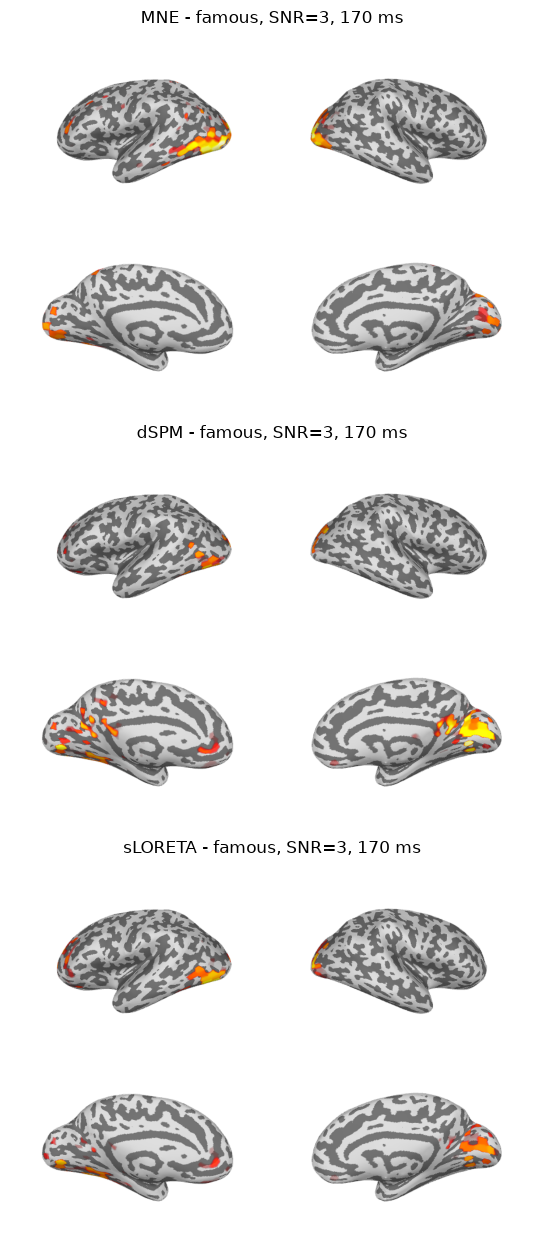

In [9]:
fig, axes = plt.subplots(len(METHODS), 1, figsize=(9, 4.2 * len(METHODS)))
for ax, method in zip(np.atleast_1d(axes), METHODS):
    stc = load_stc(COND_REF, method, SNR_REF)
    ax.imshow(brain_screenshot(stc, TIME_REF))
    ax.set_axis_off()
    ax.set_title(f"{method} - {COND_REF}, SNR={SNR_REF:g}, {TIME_REF * 1000:.0f} ms",
                 fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / f"02_methods_{COND_REF}_snr{SNR_REF:g}.png", dpi=150,
            bbox_inches="tight")

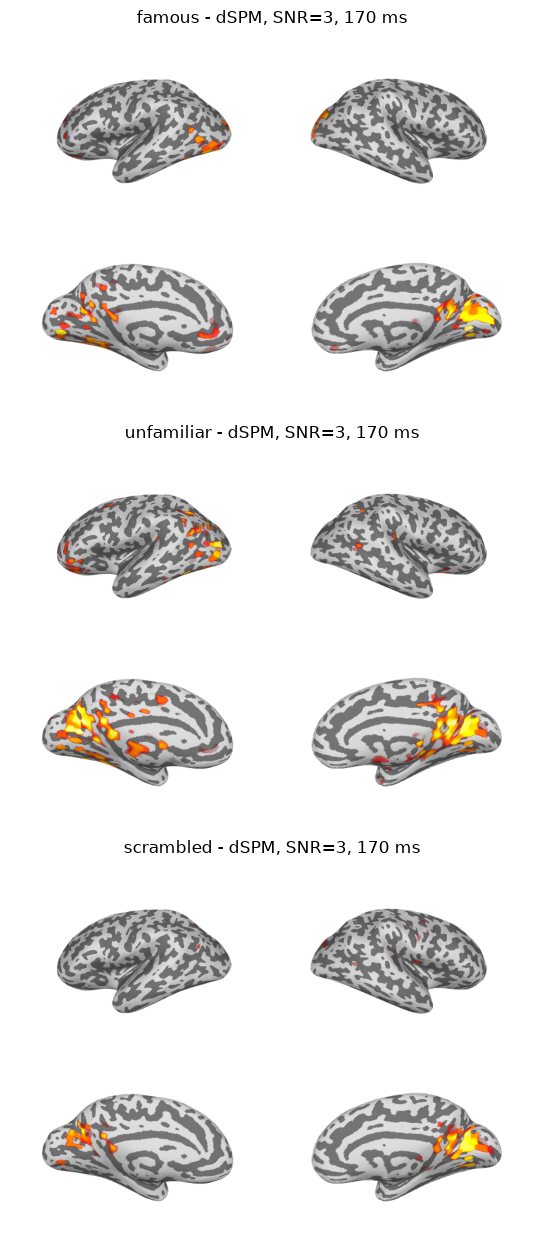

In [10]:
# Same method, the three conditions side by side
fig, axes = plt.subplots(len(CONDITIONS), 1, figsize=(9, 4.2 * len(CONDITIONS)))
for ax, cond in zip(np.atleast_1d(axes), CONDITIONS):
    stc = load_stc(cond, METHOD_REF, SNR_REF)
    ax.imshow(brain_screenshot(stc, TIME_REF))
    ax.set_axis_off()
    ax.set_title(f"{cond} - {METHOD_REF}, SNR={SNR_REF:g}, {TIME_REF * 1000:.0f} ms",
                 fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / f"02_conditions_{METHOD_REF}_snr{SNR_REF:g}.png", dpi=150,
            bbox_inches="tight")

## 3. Cortical maps: the effect of regularization

Now we fix method and condition and let the SNR vary.
Remember: low SNR → large λ² → smoother, more stable solution;
high SNR → small λ² → more detailed solution, but more sensitive to noise.

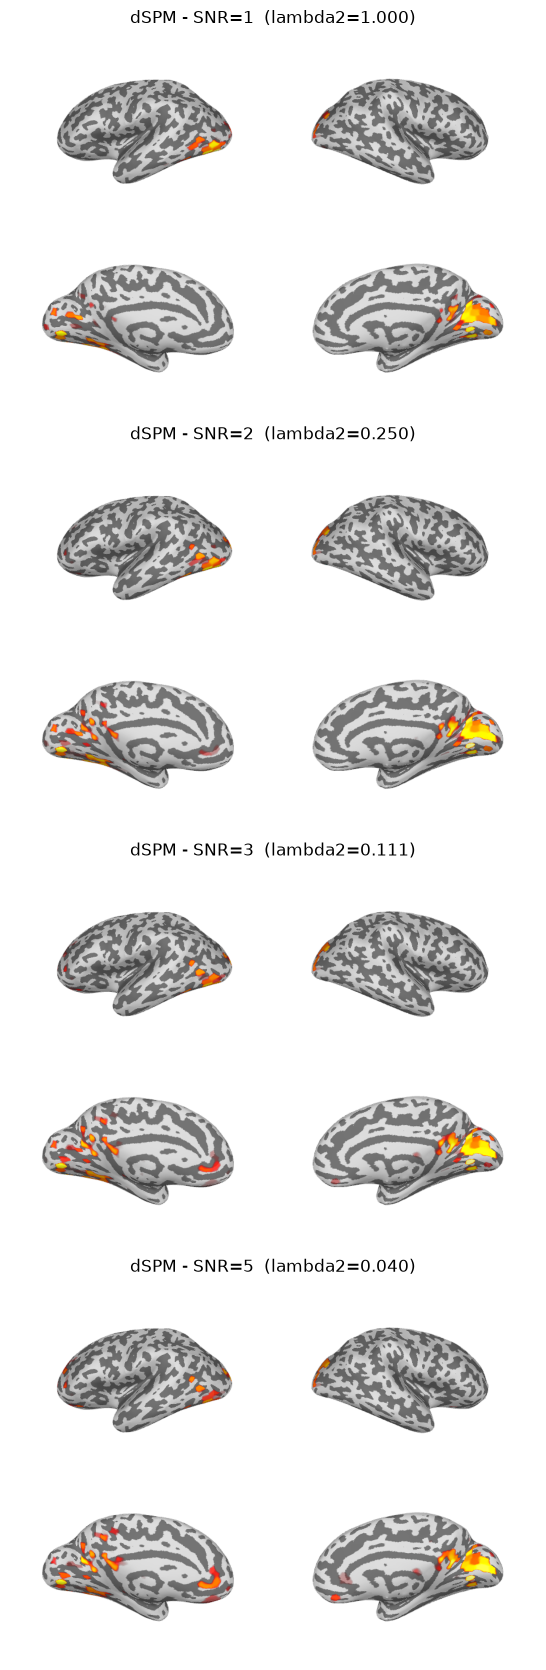

In [11]:
METHOD_REG = "dSPM"

fig, axes = plt.subplots(len(SNRS), 1, figsize=(9, 4.2 * len(SNRS)))
for ax, snr in zip(np.atleast_1d(axes), SNRS):
    stc = load_stc(COND_REF, METHOD_REG, snr)
    ax.imshow(brain_screenshot(stc, TIME_REF))
    ax.set_axis_off()
    ax.set_title(f"{METHOD_REG} - SNR={snr:g}  (lambda2={1 / snr ** 2:.3f})", fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / f"02_regularization_{METHOD_REG}_{COND_REF}.png", dpi=150,
            bbox_inches="tight")

## 4. ROI time courses

Cortical maps are striking but hard to compare by eye. ROI time courses say the same
things in a much more readable way.

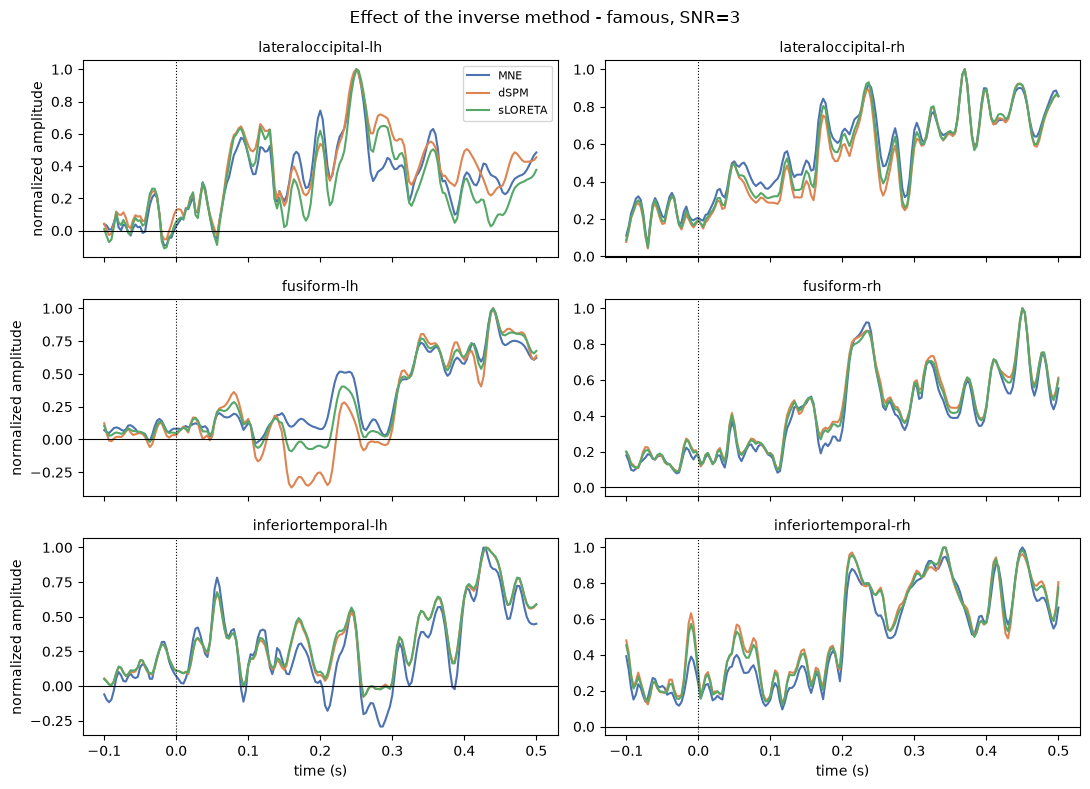

In [12]:
# 4.1 Effect of the METHOD (SNR fixed), reference condition
sel = roi_df[(roi_df.condition == COND_REF) & (roi_df.snr == SNR_REF)]

fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for ax, roi in zip(axes.ravel(), ROI_NAMES):
    for method in METHODS:
        d = sel[(sel.roi == roi) & (sel.method == method)]
        # normalization: the methods have different units, we compare shapes
        v = d["value"].to_numpy()
        v = v / np.max(np.abs(v)) if np.max(np.abs(v)) > 0 else v
        ax.plot(d["time"], v, label=method, color=METHOD_COLORS.get(method), lw=1.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_title(roi, fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("normalized amplitude")
fig.suptitle(f"Effect of the inverse method - {COND_REF}, SNR={SNR_REF:g}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_roi_by_method.png", dpi=150, bbox_inches="tight")

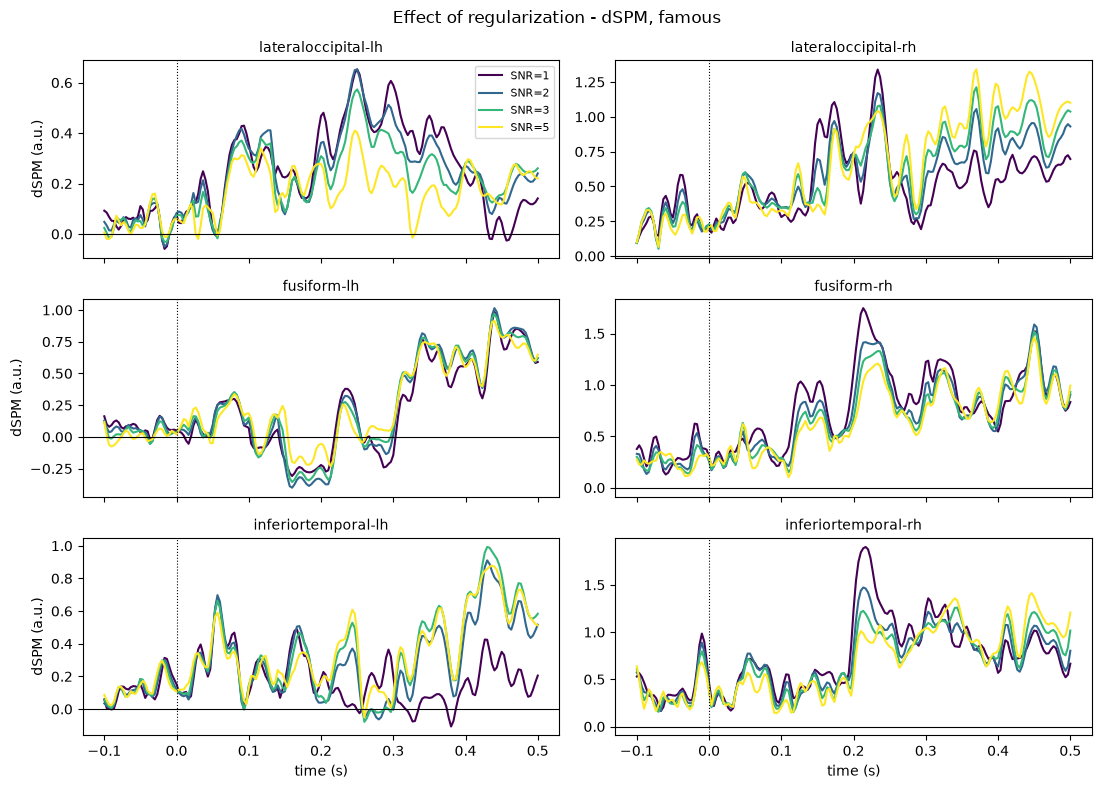

In [13]:
# 4.2 Effect of REGULARIZATION (method fixed)
sel = roi_df[(roi_df.condition == COND_REF) & (roi_df.method == METHOD_REG)]
cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for ax, roi in zip(axes.ravel(), ROI_NAMES):
    for ii, snr in enumerate(SNRS):
        d = sel[(sel.roi == roi) & (sel.snr == snr)]
        ax.plot(d["time"], d["value"], label=f"SNR={snr:g}",
                color=cmap(ii / max(len(SNRS) - 1, 1)), lw=1.5)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_title(roi, fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel(f"{METHOD_REG} (a.u.)")
fig.suptitle(f"Effect of regularization - {METHOD_REG}, {COND_REF}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_roi_by_snr.png", dpi=150, bbox_inches="tight")

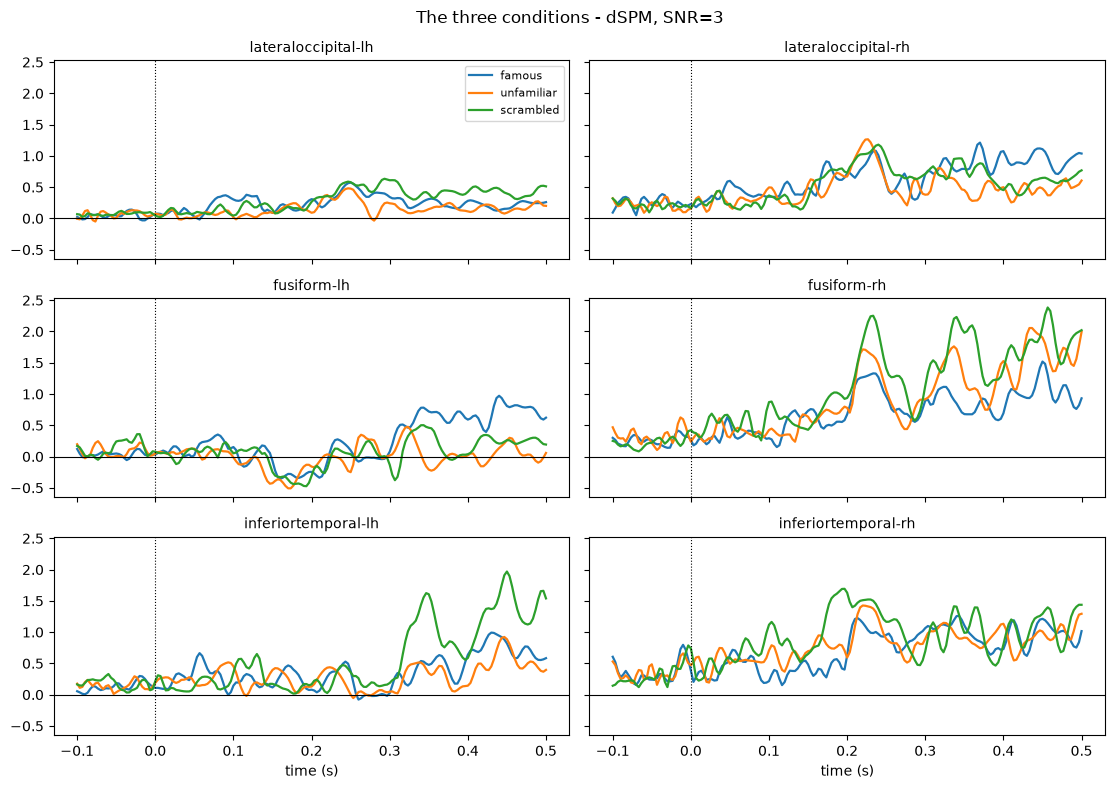

In [14]:
# 4.3 The three conditions in the reference configuration
sel = roi_df[(roi_df.method == METHOD_REF) & (roi_df.snr == SNR_REF)]

fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, roi in zip(axes.ravel(), ROI_NAMES):
    for cond in CONDITIONS:
        d = sel[(sel.roi == roi) & (sel.condition == cond)]
        ax.plot(d["time"], d["value"], label=cond, color=COLORS[cond], lw=1.6)
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_title(roi, fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"The three conditions - {METHOD_REF}, SNR={SNR_REF:g}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_roi_by_condition.png", dpi=150, bbox_inches="tight")

## 5. The peaks: latency and position

If the peak moves by several millimetres just because we changed method or
regularization, any anatomical interpretation should be taken with a grain of salt.

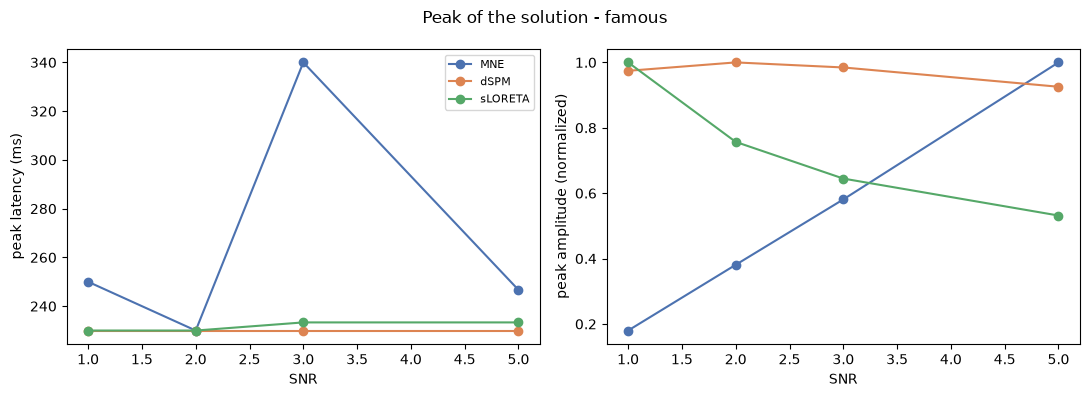

In [15]:
sub = peaks[peaks.condition == COND_REF]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for method in METHODS:
    d = sub[sub.method == method].sort_values("snr")
    axes[0].plot(d["snr"], d["peak_latency_s"] * 1000, "o-",
                 color=METHOD_COLORS.get(method), label=method)
    axes[1].plot(d["snr"], d["peak_amplitude"] / np.max(np.abs(d["peak_amplitude"])),
                 "o-", color=METHOD_COLORS.get(method), label=method)
axes[0].set_xlabel("SNR"); axes[0].set_ylabel("peak latency (ms)")
axes[1].set_xlabel("SNR"); axes[1].set_ylabel("peak amplitude (normalized)")
axes[0].legend(fontsize=8)
fig.suptitle(f"Peak of the solution - {COND_REF}")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_peak_summary.png", dpi=150, bbox_inches="tight")

In [16]:
# Peak table: hemisphere, latency, MNI coordinates
cols = ["method", "snr", "peak_hemi", "peak_latency_s", "mni_x", "mni_y", "mni_z"]
print(sub[cols].sort_values(["method", "snr"]).to_string(index=False))

 method  snr peak_hemi  peak_latency_s  mni_x  mni_y  mni_z
    MNE  1.0        lh        0.250000  -24.7  -99.2   20.6
    MNE  2.0        rh        0.230000   30.8  -95.6  -12.5
    MNE  3.0        lh        0.340000  -46.7  -73.4   -8.7
    MNE  5.0        rh        0.246667   16.7 -104.3   -1.1
   dSPM  1.0        rh        0.230000   37.8  -76.6   -7.4
   dSPM  2.0        rh        0.230000   23.3  -57.9   12.3
   dSPM  3.0        rh        0.230000   23.3  -57.9   12.3
   dSPM  5.0        rh        0.230000   23.3  -57.9   12.3
sLORETA  1.0        rh        0.230000   37.8  -76.6   -7.4
sLORETA  2.0        rh        0.230000   37.8  -76.6   -7.4
sLORETA  3.0        rh        0.233333   32.6  -75.8   -5.3
sLORETA  5.0        rh        0.233333   32.6  -75.8   -5.3


## 6. How "spread out" is the solution?

A simple but effective index: the **fraction of sources** that, at the peak instant,
exceed 50% of the maximum. The higher the index, the more diffuse the solution; the
lower, the more focal.

It is a way of putting a number on what you see when you look at the maps.

method,MNE,dSPM,sLORETA
snr,,,
1.0,0.0229,0.0712,0.0419
2.0,0.0180,0.0789,0.0521
3.0,0.0141,0.0731,0.0604
5.0,0.0136,0.0707,0.0609


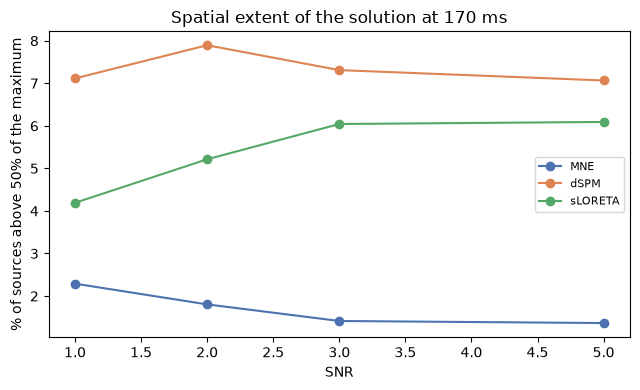

In [17]:
def spatial_extent(stc, time, threshold=0.5):
    t_idx = np.argmin(np.abs(stc.times - time))
    frame = np.abs(stc.data[:, t_idx])
    return float(np.mean(frame >= threshold * frame.max()))


rows = []
for method in METHODS:
    for snr in SNRS:
        stc = load_stc(COND_REF, method, snr)
        rows.append(dict(method=method, snr=snr,
                         extent=spatial_extent(stc, TIME_REF)))
extent = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6.5, 4))
for method in METHODS:
    d = extent[extent.method == method].sort_values("snr")
    ax.plot(d["snr"], 100 * d["extent"], "o-", color=METHOD_COLORS.get(method),
            label=method)
ax.set_xlabel("SNR")
ax.set_ylabel("% of sources above 50% of the maximum")
ax.set_title(f"Spatial extent of the solution at {TIME_REF * 1000:.0f} ms")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_spatial_extent.png", dpi=150, bbox_inches="tight")

extent.pivot(index="snr", columns="method", values="extent").round(4)

---

# 7. Your turn

The grid computed in notebook 01 is on disk: 36 solutions you can call up in a
fraction of a second. Here you decide what to compare.

* **7.1-7.2**: fill in the blanks (`...`) and build your own comparison figure.
* **7.3-7.4**: menus and sliders to browse the whole grid, plus a button to open
  any combination in the interactive 3D window.

## 7.1 Choose your comparison

Two methods, one SNR, one condition, one instant. Only combinations that notebook 01
actually saved are available: the cell below prints them, so you know exactly what
you can pick.

In [18]:
# What is available on disk, i.e. what notebook 01 saved
_t = load_stc(COND_REF, METHOD_REF, SNR_REF).times
TIME_RANGE = (float(_t[0]), float(_t[-1]))

print("conditions :", CONDITIONS)
print("methods    :", METHODS)
print("SNR values :", [f"{s:g}" for s in SNRS])
print(f"time range : {TIME_RANGE[0]:+.3f} .. {TIME_RANGE[1]:+.3f} s "
      f"({len(_t)} samples, step {1000 * (_t[1] - _t[0]):.1f} ms)")
print("\nROIs       :", ROI_NAMES)

conditions : ['famous', 'unfamiliar', 'scrambled']
methods    : ['MNE', 'dSPM', 'sLORETA']
SNR values : ['1', '2', '3', '5']
time range : -0.100 .. +0.500 s (181 samples, step 3.3 ms)

ROIs       : ['lateraloccipital-lh', 'lateraloccipital-rh', 'fusiform-lh', 'fusiform-rh', 'inferiortemporal-lh', 'inferiortemporal-rh']


In [19]:
def check_available(condition=None, method=None, snr=None, time=None):
    """Check that a combination was actually saved by notebook 01."""
    problems = []
    if condition is Ellipsis or condition not in CONDITIONS:
        problems.append(f"condition={condition!r}: pick one of {CONDITIONS}")
    if method is Ellipsis or method not in METHODS:
        problems.append(f"method={method!r}: pick one of {METHODS}")
    if snr is Ellipsis or snr not in SNRS:
        problems.append(f"snr={snr!r}: pick one of {SNRS} "
                        "(or rerun the grid in notebook 01 with more values)")
    if time is not None:
        if time is Ellipsis or not isinstance(time, (int, float)):
            problems.append("time: a latency in SECONDS, e.g. 0.17")
        elif not TIME_RANGE[0] <= time <= TIME_RANGE[1]:
            problems.append(f"time={time}: outside the saved window "
                            f"{TIME_RANGE[0]:+.3f} .. {TIME_RANGE[1]:+.3f} s")

    for p in problems:
        print("  -", p)
    if not problems:
        print(f"available: {condition}, {method}, SNR={snr:g}")
    return not problems

In [22]:
# ----------------------------------------------------------------------
# TODO 1 - two methods to put side by side.
#          Allowed: "MNE", "dSPM", "sLORETA"   (whatever METHODS contains)
MY_METHODS = [..., ...]

# TODO 2 - at which SNR?
#          Allowed: 1.0, 2.0, 3.0, 5.0   (the values in SNRS, saved by notebook 01)
MY_SNR = ...

# TODO 3 - which condition?
#          Allowed: "famous", "unfamiliar", "scrambled"
MY_CONDITION = ...

# TODO 4 - at which latency, in SECONDS?
#          Anywhere inside the saved window printed above (about -0.100 .. +0.500 s).
#          0.17 is the N170 peak; 0.0 is stimulus onset; 0.25-0.35 is the late response.
MY_TIME = ...

all(check_available(MY_CONDITION, m, MY_SNR, MY_TIME) for m in MY_METHODS)

available: famous, MNE, SNR=3
available: famous, dSPM, SNR=3


True

## 7.2 Build the figure

`brain_screenshot` (section 2) does the rendering: you only have to say what to put
in each panel.

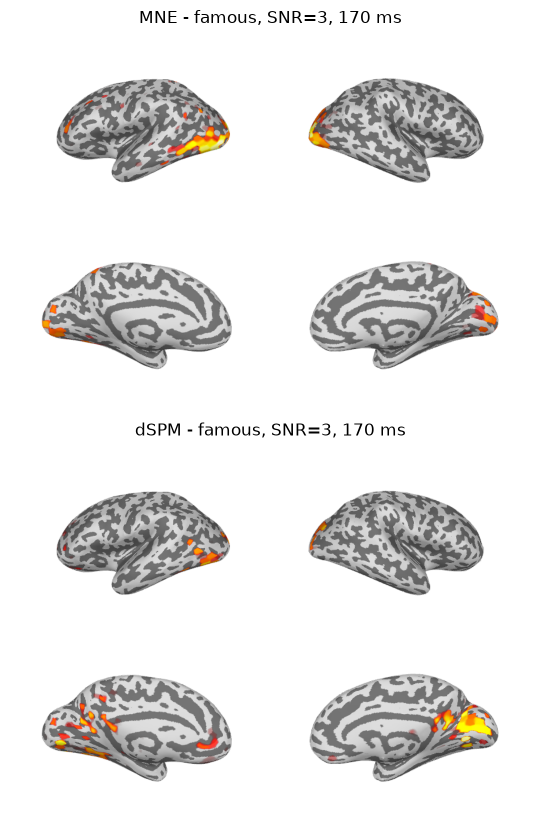

In [27]:
fig, axes = plt.subplots(len(MY_METHODS), 1, figsize=(9, 4.2 * len(MY_METHODS)))
for ax, method in zip(np.atleast_1d(axes), MY_METHODS):
    stc = load_stc(MY_CONDITION, method, MY_SNR)      
    ax.imshow(brain_screenshot(stc, MY_TIME))          
    ax.set_axis_off()
    ax.set_title(f"{method} - {MY_CONDITION}, SNR={MY_SNR:g}, {MY_TIME * 1000:.0f} ms",
                 fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_my_comparison.png", dpi=150, bbox_inches="tight")

## 7.3 Browse the grid with sliders

These controls read the CSV files, so they update instantly: nothing is recomputed.
Move the SNR slider and watch the ROI time course breathe.

In [28]:
import ipywidgets as widgets

w_condition = widgets.Dropdown(options=CONDITIONS, value=COND_REF, description="condition:")
w_roi = widgets.Dropdown(options=ROI_NAMES, value="fusiform-rh", description="ROI:")
w_snr = widgets.SelectionSlider(options=[(f"{s:g}", s) for s in SNRS], value=SNR_REF,
                                description="SNR:", continuous_update=False)
w_normalize = widgets.Checkbox(value=True, description="normalize amplitudes")


def browse_roi(condition, roi, snr, normalize):
    """ROI time course for the three methods, at the chosen SNR."""
    sel = roi_df[(roi_df.condition == condition) & (roi_df.snr == snr)
                 & (roi_df.roi == roi)]

    fig, ax = plt.subplots(figsize=(8.5, 4))
    for method in METHODS:
        d = sel[sel.method == method]
        v = d["value"].to_numpy()
        if normalize and np.abs(v).max() > 0:
            v = v / np.abs(v).max()
        ax.plot(d["time"], v, lw=1.7, color=METHOD_COLORS.get(method), label=method)

    for method in METHODS:
        row = peaks[(peaks.condition == condition) & (peaks.method == method)
                    & (peaks.snr == snr)]
        if len(row):
            ax.axvline(row["peak_latency_s"].iloc[0], lw=1, ls="--",
                       color=METHOD_COLORS.get(method), alpha=0.5)

    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8, ls=":")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("normalized amplitude" if normalize else "a.u.")
    ax.set_title(f"{roi} - {condition}, SNR={snr:g}  "
                 f"(dashed lines: whole-brain peak of each method)")
    ax.legend(fontsize=8)
    plt.show()


widgets.interact(browse_roi, condition=w_condition, roi=w_roi, snr=w_snr,
                 normalize=w_normalize);

interactive(children=(Dropdown(description='condition:', options=('famous', 'unfamiliar', 'scrambled'), value=…

## 7.4 Open any combination in the 3D window

Pick a combination, press **Run Interact**, and the interactive viewer opens with
that solution. Close the window before opening the next one, or they will pile up.

In [29]:
w3_condition = widgets.Dropdown(options=CONDITIONS, value=COND_REF, description="condition:")
w3_method = widgets.Dropdown(options=METHODS, value=METHOD_REF, description="method:")
w3_snr = widgets.SelectionSlider(options=[(f"{s:g}", s) for s in SNRS], value=SNR_REF,
                                 description="SNR:")
w3_time = widgets.FloatSlider(value=TIME_REF, min=0.0, max=0.5, step=0.005,
                              description="time (s):", readout_format=".3f")
w3_surface = widgets.Dropdown(options=["inflated", "white", "pial"],
                              value="inflated", description="surface:")

open_brains = []


def open_viewer(condition, method, snr, time, surface):
    stc = load_stc(condition, method, snr)
    b = stc.plot(
        subject=SUBJECT, subjects_dir=SUBJECTS_DIR,
        surface=surface, hemi="both", views="lateral",
        initial_time=time, time_unit="s",
        time_viewer=True, show_traces=True,
        size=(950, 680), background="white",
        title=f"{condition} - {method}, SNR={snr:g}",
    )
    open_brains.append(b)
    print(f"window opened: {condition}, {method}, SNR={snr:g}, {time * 1000:.0f} ms")


widgets.interact_manual(open_viewer, condition=w3_condition, method=w3_method,
                        snr=w3_snr, time=w3_time, surface=w3_surface);

interactive(children=(Dropdown(description='condition:', options=('famous', 'unfamiliar', 'scrambled'), value=…